# v12 — De-redundant scoring: kurangi duplikasi antar-indikator yang berkorelasi tinggi

**Latar belakang:** analisis korelasi 20 kategori skor `generate_signal()` (di seluruh ~107K candle
2025-2026) menemukan redundansi kuat:

- **Cluster oscillator** (RSI, Stochastic, Williams %R, CCI, Bollinger Bands, VWAP): korelasi
  antar-pasangan 0.67-0.94 (Stoch vs Williams %R = 0.94, nyaris duplikat sempurna)
- **Cluster trend-follower** (SMA, Ichimoku, Supertrend): korelasi 0.65-0.71
- **SMC** hampir tidak berkorelasi dengan kategori lain manapun (semua < 0.2) — sumber informasi
  independen, bukan duplikat
- **MFI** juga relatif independen dari cluster oscillator lain (korelasi tertinggi cuma ~0.37)

**Analisis susulan (breadth vs depth, dari trade_log v06 yang sudah ada, TANPA ubah kode):**
membandingkan trade dengan skor tinggi karena "breadth" (banyak kategori align bersamaan, banyak dari
cluster oscillator redundan) vs skor tinggi karena "depth" (SMC berkontribusi signifikan). Di antara
trade dengan |signal_score| >= median: yang SMC-driven win rate **55.7%**, yang breadth/oscillator-
driven (SMC tidak signifikan) cuma **41.4%** — breadth tinggi TIDAK menjamin kualitas sinyal lebih
baik, malah sebaliknya. Ini indikasi kuat bahwa scoring saat ini kadang menghasilkan skor total
tinggi yang "palsu" — bukan konfirmasi independen, tapi 1-2 kondisi market yang sama diulang lewat
banyak formula oscillator berbeda.

**Ide v12:** redesain scoring supaya kategori yang berkorelasi tinggi digabung jadi 1 skor komposit
(median dari anggota cluster, bukan dijumlah semua) — mengurangi "pemberatan ganda" dari sinyal yang
sebenarnya sama, sambil TETAP mempertahankan kategori independen (SMC, MFI, ADX, momentum_chain, dst)
apa adanya.

**Metodologi validasi (belajar dari kegagalan REVERSE & SMALL-REVERSE di v10):**
1. Skema pengelompokan ditentukan dari korelasi (fakta objektif), bukan trial-and-error
2. Grid search threshold BARU (skala skor total berubah krn komposit) dilakukan HANYA di TRAIN
   (2025-01 s/d 2026-02)
3. TEST (2026-03 s/d 2026-08, out-of-sample) dipakai HANYA untuk validasi independen, TIDAK
   di-tuning ulang
4. Filter Order Block v10-SKIP tetap dipertahankan (sudah terbukti robust, di luar scope
   redundansi oscillator)
5. Kriteria lolos: v12 harus lebih baik dari v06+SKIP baseline DI TEST, bukan cuma TRAIN

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals.scoring import (
    score_adx, score_bb, score_cci, score_candle, score_extra_patterns,
    score_fibonacci, score_ichimoku, score_macd, score_mfi, score_momentum_chain,
    score_obv, score_psar, score_rsi, score_rsi_divergence, score_sma, score_smc,
    score_stoch, score_supertrend, score_vwap, score_williams_r,
)

STRATEGY_NAME = "m5_scalping"
VERSION = "v12"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (sama seperti v06/v10)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

BACKTEST_START = "2025-01-01"
TRAIN_END = "2026-03-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)
print("M5 + konteks H1:", df_bt.shape, df_bt["datetime"].min(), "->", df_bt["datetime"].max())

M5 + konteks H1: (107336, 159) 2025-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Scoring de-redundant — gabungkan cluster berkorelasi tinggi jadi 1 skor komposit

Skema pengelompokan (dari correlation matrix, bukan tebakan):
- **`oscillator_composite`**: median(RSI, Stoch, Williams %R, CCI, BB, VWAP) — korelasi 0.67-0.94
  antar-pasangan, digabung jadi 1 nilai representatif alih-alih dijumlah 6x
- **`trend_composite`**: median(SMA, Ichimoku, Supertrend) — korelasi 0.65-0.71
- **Independen, TIDAK digabung** (korelasi rendah thd cluster manapun): MACD, ADX, Candle,
  Extra patterns, OBV, MFI, Fibonacci, RSI divergence, Momentum chain, PSAR, SMC

Bobot komposit = rata-rata bobot anggota cluster asli (supaya skala total skor tetap sebanding,
bukan asal comot angka baru).

In [3]:
OSCILLATOR_CLUSTER = ["rsi", "stoch", "williams_r", "cci", "bb", "vwap"]
TREND_CLUSTER = ["sma", "ichimoku", "supertrend"]

OLD_WEIGHTS = {
    "rsi": 1.0, "macd": 1.0, "ema": 1.5, "bb": 1.0, "stoch": 1.0, "adx": 1.5, "candle": 1.0,
    "obv": 1.5, "vwap": 1.5, "williams_r": 1.0, "cci": 1.0, "mfi": 1.5, "sma": 1.5,
    "fibonacci": 2.0, "rsi_div": 4.0, "momentum_chain": 2.0, "supertrend": 2.5, "psar": 1.5,
    "ichimoku": 2.5, "smc": 3.0, "pattern_ex": 1.5,
}

# Bobot komposit = rata2 bobot anggota asli -- skala total skor akhir jadi sebanding dgn skema lama
OSCILLATOR_WEIGHT = round(np.mean([OLD_WEIGHTS["rsi"], OLD_WEIGHTS["stoch"], OLD_WEIGHTS["williams_r"],
                                     OLD_WEIGHTS["cci"], OLD_WEIGHTS["bb"], OLD_WEIGHTS["vwap"]]), 2)
TREND_WEIGHT = round(np.mean([OLD_WEIGHTS["sma"], OLD_WEIGHTS["ichimoku"], OLD_WEIGHTS["supertrend"]]), 2)
print(f"oscillator_composite weight (avg): {OSCILLATOR_WEIGHT}")
print(f"trend_composite weight (avg): {TREND_WEIGHT}")


def score_de_redundant(row: pd.Series) -> tuple[float, dict[str, float]]:
    """Hitung ulang skor per kategori asli (raw, TANPA bobot dulu), lalu gabungkan cluster
    berkorelasi tinggi jadi median (bukan sum) sebelum dikali bobot komposit. Kategori
    independen tetap dipakai apa adanya dari fungsi asli (sudah termasuk bobotnya)."""
    close = float(row["close"])
    atr = float(row.get("atr", close * 0.001))

    raw_scores = {
        "rsi": score_rsi(row)[0] / OLD_WEIGHTS["rsi"],
        "stoch": score_stoch(row)[0] / OLD_WEIGHTS["stoch"],
        "williams_r": score_williams_r(row)[0] / OLD_WEIGHTS["williams_r"],
        "cci": score_cci(row)[0] / OLD_WEIGHTS["cci"],
        "bb": score_bb(row, close)[0] / OLD_WEIGHTS["bb"],
        "vwap": score_vwap(row, close)[0] / OLD_WEIGHTS["vwap"],
        "sma": score_sma(row, close)[0] / OLD_WEIGHTS["sma"],
        "ichimoku": score_ichimoku(row, close)[0] / OLD_WEIGHTS["ichimoku"],
        "supertrend": score_supertrend(row)[0] / OLD_WEIGHTS["supertrend"],
    }

    oscillator_raw = np.median([raw_scores[c] for c in OSCILLATOR_CLUSTER])
    trend_raw = np.median([raw_scores[c] for c in TREND_CLUSTER])

    components = {
        "oscillator_composite": oscillator_raw * OSCILLATOR_WEIGHT,
        "trend_composite": trend_raw * TREND_WEIGHT,
        "macd": score_macd(row)[0],
        "adx": score_adx(row)[0],
        "candle": score_candle(row)[0],
        "extra_patterns": score_extra_patterns(row)[0],
        "obv": score_obv(row)[0],
        "mfi": score_mfi(row)[0],
        "fibonacci": score_fibonacci(row, close, atr)[0],
        "rsi_divergence": score_rsi_divergence(row)[0],
        "momentum_chain": score_momentum_chain(row)[0],
        "psar": score_psar(row)[0],
        "smc": score_smc(row)[0],
    }

    final_score = round(sum(components.values()), 3)
    return final_score, components

oscillator_composite weight (avg): 1.08
trend_composite weight (avg): 2.17


## 3. Bandingkan skala skor lama vs baru (sanity check sebelum grid search threshold)

In [4]:
from app.utils.signals import generate_signal

sample = df_bt.iloc[::500].copy()  # sample tiap 500 candle biar cepat, cukup buat cek skala
old_scores = []
new_scores = []
for _, row in sample.iterrows():
    old_result = generate_signal(row, min_signal_score=0.01, adx_min=0, atr_min_pct=0)
    new_score, _ = score_de_redundant(row)
    old_scores.append(old_result.final_score)
    new_scores.append(new_score)

sample["old_score"] = old_scores
sample["new_score"] = new_scores
print("Skala skor LAMA (20 kategori penuh):")
print(sample["old_score"].abs().describe())
print()
print("Skala skor BARU (de-redundant):")
print(sample["new_score"].abs().describe())

Skala skor LAMA (20 kategori penuh):
count    215.000000
mean       4.345321
std        2.682778
min        0.050000
25%        2.225000
50%        4.138000
75%        6.117000
max       10.950000
Name: old_score, dtype: float64

Skala skor BARU (de-redundant):
count    215.000000
mean       3.653670
std        2.525238
min        0.108000
25%        1.622500
50%        3.150000
75%        5.449000
max       10.372000
Name: new_score, dtype: float64


## 4. Generate sinyal de-redundant utk TRAIN & TEST (belum tentukan threshold dulu)

Filter keras (ADX, ATR%, H1 alignment) TETAP SAMA seperti v06 -- yang diubah cuma cara scoring
kategori, bukan filter di luar itu.

In [5]:
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03


def check_hard_filters(row: pd.Series, close: float) -> bool:
    adx = row.get("adx", 0)
    if adx < ADX_MIN:
        return False
    atr = row.get("atr", 0)
    if close > 0 and (atr / close * 100) < ATR_MIN_PCT:
        return False
    return True


def check_h1_alignment(row: pd.Series, direction: str) -> bool:
    h1_ema_50 = row.get("h1_ema_50")
    h1_ema_200 = row.get("h1_ema_200")
    if h1_ema_50 is None or h1_ema_200 is None or pd.isna(h1_ema_50) or pd.isna(h1_ema_200):
        return True
    h1_trend = "UP" if h1_ema_50 > h1_ema_200 else ("DOWN" if h1_ema_50 < h1_ema_200 else "FLAT")
    if direction == "BUY" and h1_trend == "DOWN":
        return False
    if direction == "SELL" and h1_trend == "UP":
        return False
    return True


def has_opposing_ob(row: pd.Series, direction: str) -> bool:
    if direction == "BUY":
        return bool(row["ob_bear"] > 0 or row["h1_ob_bear"] > 0)
    return bool(row["ob_bull"] > 0 or row["h1_ob_bull"] > 0)


def generate_signal_v12(row: pd.Series, min_signal_score: float) -> tuple[str, float]:
    close = float(row["close"])
    if not check_hard_filters(row, close):
        return "WAIT", 0.0

    final_score, _ = score_de_redundant(row)

    if final_score >= min_signal_score:
        direction = "BUY"
    elif final_score <= -min_signal_score:
        direction = "SELL"
    else:
        return "WAIT", final_score

    if not check_h1_alignment(row, direction):
        return "WAIT", final_score
    if has_opposing_ob(row, direction):
        return "WAIT", final_score

    return direction, final_score


print("Generating v12 raw scores (threshold=0, biar bisa grid search nanti) utk semua candle...")
print("NOTE: ini proses row-by-row ~107K baris, akan makan waktu beberapa menit.")

all_scores = []
for _, row in df_bt.iterrows():
    close = float(row["close"])
    if not check_hard_filters(row, close):
        all_scores.append(np.nan)
        continue
    final_score, _ = score_de_redundant(row)
    all_scores.append(final_score)

df_bt["v12_raw_score"] = all_scores
print("Done. Non-null (lolos hard filter):", df_bt["v12_raw_score"].notna().sum())

Generating v12 raw scores (threshold=0, biar bisa grid search nanti) utk semua candle...
NOTE: ini proses row-by-row ~107K baris, akan makan waktu beberapa menit.


Done. Non-null (lolos hard filter): 76825


## 5. Backtest engine (sama seperti v06/v10, pakai `v12_raw_score` + threshold sbg parameter)

In [6]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30
SL_MULT = 2.0
TP_MULT = 4.0
MAX_HOLD_CANDLES = 12

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime", "v12_raw_score")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def build_direction_column(df_signals: pd.DataFrame, min_signal_score: float) -> pd.Series:
    score = df_signals["v12_raw_score"]
    direction = pd.Series("WAIT", index=df_signals.index)
    direction[score >= min_signal_score] = "BUY"
    direction[score <= -min_signal_score] = "SELL"

    # H1 alignment + OB filter, diterapkan setelah threshold (sama urutan kayak generate_signal_v12)
    for idx in direction[direction != "WAIT"].index:
        row = df_signals.loc[idx]
        d = direction.loc[idx]
        if not check_h1_alignment(row, d) or has_opposing_ob(row, d):
            direction.loc[idx] = "WAIT"
    return direction


def run_backtest(df_signals: pd.DataFrame, min_signal_score: float,
                  save_full_log: bool = False) -> tuple[pd.DataFrame, list[float]]:
    df_signals = df_signals.copy()
    df_signals["signal_direction"] = build_direction_column(df_signals, min_signal_score)

    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = SL_MULT * atr
        tp_points = TP_MULT * atr
        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price: float | None = None
        exit_time = None
        exit_reason = None
        exit_idx = min(i + MAX_HOLD_CANDLES, n - 1)

        window_end = min(i + 1 + MAX_HOLD_CANDLES, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price
            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                exit_idx = candle_idx
                break

        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"

        next_i = exit_idx + 1
        hold_candles = exit_idx - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "atr_at_entry": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": row["v12_raw_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}
    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

## 6. Grid search threshold BARU di TRAIN (2025-01 s/d 2026-02)

In [7]:
df_train = df_bt[df_bt["datetime"] < TRAIN_END].reset_index(drop=True)
df_test = df_bt[df_bt["datetime"] >= TRAIN_END].reset_index(drop=True)
print(f"TRAIN: {len(df_train)} baris, TEST: {len(df_test)} baris")

threshold_candidates = [4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

grid_results = []
for th in threshold_candidates:
    trades, _ = run_backtest(df_train, th)
    metrics = evaluate(trades, INITIAL_EQUITY)
    metrics["min_signal_score"] = th
    grid_results.append(metrics)
    print(f"threshold={th:4.1f} -> trades={metrics.get('total_trades',0):5d} "
          f"win_rate={metrics.get('win_rate_pct',0):5.1f}% PF={metrics.get('profit_factor',0):5.2f} "
          f"final_equity=${metrics.get('final_equity',0):8.2f}")

grid_df = pd.DataFrame(grid_results).sort_values("final_equity", ascending=False)
print()
print("=== Top kombinasi threshold TRAIN ===")
grid_df

TRAIN: 77226 baris, TEST: 30110 baris


threshold= 4.0 -> trades= 1968 win_rate= 58.1% PF= 1.89 final_equity=$20939.31


threshold= 5.0 -> trades= 1727 win_rate= 58.4% PF= 1.99 final_equity=$18114.01


threshold= 6.0 -> trades= 1431 win_rate= 59.5% PF= 2.32 final_equity=$14516.13


threshold= 7.0 -> trades= 1129 win_rate= 59.7% PF= 2.55 final_equity=$ 7155.76


threshold= 8.0 -> trades=  814 win_rate= 60.9% PF= 2.56 final_equity=$ 3562.15


threshold= 9.0 -> trades=  507 win_rate= 64.9% PF= 2.90 final_equity=$ 2072.55


threshold=10.0 -> trades=  269 win_rate= 63.2% PF= 2.51 final_equity=$  914.45

=== Top kombinasi threshold TRAIN ===


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,min_signal_score
0,1968,58.13,1.89,20839.31,20939.31,-19.44,80.56,305,68.33,6.45,4.0
1,1727,58.37,1.99,18014.01,18114.01,-23.57,76.43,304,59.26,5.68,5.0
2,1431,59.54,2.32,14416.13,14516.13,-29.79,70.21,292,49.37,4.90,6.0
3,1129,59.70,2.55,7055.76,7155.76,-10.52,91.64,278,25.38,4.06,7.0
4,814,60.93,2.56,3462.15,3562.15,-13.00,95.42,261,13.26,3.12,8.0
5,507,64.89,2.90,1972.55,2072.55,-7.24,97.67,221,8.93,2.29,9.0
6,269,63.20,2.51,814.45,914.45,-7.84,95.39,171,4.76,1.57,10.0


## 7. Validasi TEST (out-of-sample) — threshold FIXED dari TRAIN, tidak di-tuning ulang

In [8]:
best_threshold = float(grid_df.iloc[0]["min_signal_score"])
print(f"Threshold terpilih dari TRAIN: {best_threshold}")

trades_test_v12, curve_test_v12 = run_backtest(df_test, best_threshold, save_full_log=True)
metrics_test_v12 = evaluate(trades_test_v12, INITIAL_EQUITY)

print("\n=== v12 (de-redundant scoring) — TEST out-of-sample ===")
for k, v in metrics_test_v12.items():
    print(f"  {k}: {v}")

Threshold terpilih dari TRAIN: 4.0



=== v12 (de-redundant scoring) — TEST out-of-sample ===
  total_trades: 762
  win_rate_pct: 58.53
  profit_factor: 1.91
  net_pnl: 5801.36
  final_equity: 5901.36
  max_drawdown_pct: -28.57
  min_equity: 100.0
  trading_days: 123
  avg_daily_pnl: 47.17
  avg_trades_per_day: 6.2


## 8. Baseline v06+SKIP di TEST yang sama (buat perbandingan apple-to-apple)

In [9]:
def run_backtest_v06(df_signals: pd.DataFrame) -> tuple[pd.DataFrame, list[float]]:
    """v06 asli + SKIP order block, MIN_SIGNAL_SCORE=9.0 (baseline final yang sudah live)."""
    df_signals = df_signals.copy()
    directions = np.empty(len(df_signals), dtype=object)
    scores = np.zeros(len(df_signals))
    for pos, (_, row) in enumerate(df_signals.iterrows()):
        result = generate_signal(row, 9.0, ADX_MIN, ATR_MIN_PCT, True)
        direction = result.direction
        if direction != "WAIT" and has_opposing_ob(row, direction):
            direction = "WAIT"
        directions[pos] = direction
        scores[pos] = result.final_score
    df_signals["signal_direction"] = directions
    df_signals["v12_raw_score"] = scores  # reuse kolom biar run_backtest generic-nya jalan

    # run_backtest butuh 'v12_raw_score' & threshold match direction yg SUDAH dihitung -- pakai
    # threshold ekstrem (won't override) & direction sudah final dari signal_direction manual
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)
    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]
        if direction == "WAIT":
            i += 1
            continue
        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue
        sl_points = SL_MULT * atr
        tp_points = TP_MULT * atr
        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]
        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points
        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity
        exit_price = None
        exit_time = None
        exit_reason = None
        exit_idx = min(i + MAX_HOLD_CANDLES, n - 1)
        window_end = min(i + 1 + MAX_HOLD_CANDLES, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price
            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                exit_idx = candle_idx
                break
        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
        next_i = exit_idx + 1
        hold_candles = exit_idx - i
        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)
        trades.append({
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "pnl": pnl, "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "equity_before": equity_before, "equity_after": equity,
        })
        i = next_i
    return pd.DataFrame(trades), equity_curve


trades_test_v06, curve_test_v06 = run_backtest_v06(df_test)
metrics_test_v06 = evaluate(trades_test_v06, INITIAL_EQUITY)

comparison = pd.DataFrame({
    "TEST — v06+SKIP baseline": metrics_test_v06,
    f"TEST — v12 de-redundant (th={best_threshold})": metrics_test_v12,
})
print("=== Perbandingan TEST set (out-of-sample) ===")
comparison

=== Perbandingan TEST set (out-of-sample) ===


,TEST — v06+SKIP baseline,TEST — v12 de-redundant (th=4.0)
total_trades,315.00,762.00
win_rate_pct,60.95,58.53
profit_factor,2.32,1.91
net_pnl,1615.83,5801.36
final_equity,1715.83,5901.36
max_drawdown_pct,-53.93,-28.57
min_equity,46.07,100.00
trading_days,99.00,123.00
avg_daily_pnl,16.32,47.17
avg_trades_per_day,3.18,6.20


## 9. Equity curve — TEST set

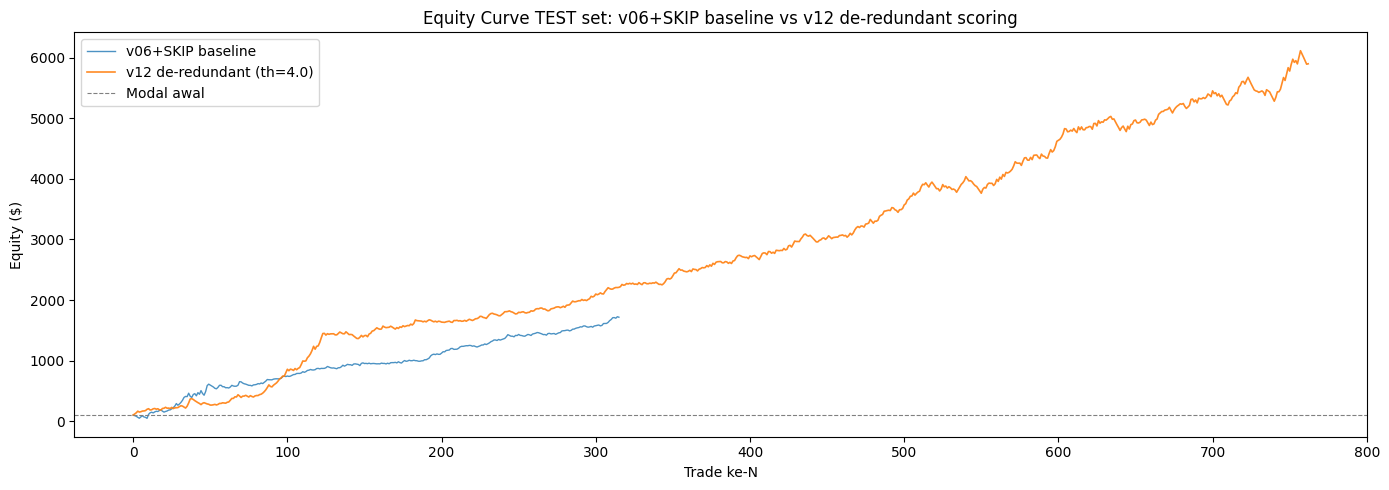

In [10]:
fig, ax = plt.subplots()
ax.plot(curve_test_v06, label="v06+SKIP baseline", alpha=0.8, linewidth=1.0)
ax.plot(curve_test_v12, label=f"v12 de-redundant (th={best_threshold})", alpha=0.9, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title("Equity Curve TEST set: v06+SKIP baseline vs v12 de-redundant scoring")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve_test_comparison.png", dpi=120)
plt.show()

## 10. Kesimpulan & keputusan

Kriteria v12 layak dipakai: harus lebih baik dari v06+SKIP baseline DI TEST (out-of-sample), bukan
cuma TRAIN — dan idealnya konsisten (TRAIN & TEST sama-sama lebih baik, bukan cuma salah satu).

In [11]:
print("=== Checklist keputusan ===")
print()
print(f"Win rate TEST: v06+SKIP={metrics_test_v06['win_rate_pct']}%, v12={metrics_test_v12['win_rate_pct']}%")
print(f"Profit factor TEST: v06+SKIP={metrics_test_v06['profit_factor']}, v12={metrics_test_v12['profit_factor']}")
print(f"Net PnL TEST: v06+SKIP={metrics_test_v06['net_pnl']}, v12={metrics_test_v12['net_pnl']}")
print(f"Max drawdown TEST: v06+SKIP={metrics_test_v06['max_drawdown_pct']}%, v12={metrics_test_v12['max_drawdown_pct']}%")
print()
better_pf = metrics_test_v12["profit_factor"] > metrics_test_v06["profit_factor"]
better_pnl = metrics_test_v12["net_pnl"] > metrics_test_v06["net_pnl"]
print(f"v12 PF lebih baik dari baseline di TEST: {better_pf}")
print(f"v12 net_pnl lebih baik dari baseline di TEST: {better_pnl}")
print(f"-> {'v12 LAYAK dipertimbangkan' if (better_pf and better_pnl) else 'v12 BELUM terbukti lebih baik, perlu investigasi lanjut'}")

=== Checklist keputusan ===

Win rate TEST: v06+SKIP=60.95%, v12=58.53%
Profit factor TEST: v06+SKIP=2.32, v12=1.91
Net PnL TEST: v06+SKIP=1615.83, v12=5801.36
Max drawdown TEST: v06+SKIP=-53.93%, v12=-28.57%

v12 PF lebih baik dari baseline di TEST: False
v12 net_pnl lebih baik dari baseline di TEST: True
-> v12 BELUM terbukti lebih baik, perlu investigasi lanjut


## 11. Simpan hasil

In [12]:
trades_test_v12.to_csv(PROCESSED_OUT_DIR / "trade_log_test_v12.csv", index=False)
grid_df.to_csv(EXPORT_DIR / "grid_search_train_threshold.csv", index=False)
comparison.to_csv(EXPORT_DIR / "comparison_v06_vs_v12.csv")

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Backtest v12 -- De-redundant scoring (gabung cluster oscillator & trend-follower)\n\n")
    f.write(f"oscillator_composite = median(rsi,stoch,williams_r,cci,bb,vwap) x {OSCILLATOR_WEIGHT}\n")
    f.write(f"trend_composite = median(sma,ichimoku,supertrend) x {TREND_WEIGHT}\n")
    f.write(f"Threshold terpilih dari TRAIN grid search: {best_threshold}\n\n")
    f.write("=== TRAIN grid search (2025-01 s/d 2026-02) ===\n")
    f.write(grid_df.to_string())
    f.write("\n\n=== TEST (2026-03 s/d 2026-08, out-of-sample) ===\n")
    f.write("v06+SKIP baseline:\n")
    for k, v in metrics_test_v06.items():
        f.write(f"  {k}: {v}\n")
    f.write("v12 de-redundant:\n")
    for k, v in metrics_test_v12.items():
        f.write(f"  {k}: {v}\n")

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v12
 - comparison_v06_vs_v12.csv
 - equity_curve_test_comparison.png
 - grid_search_train_threshold.csv
 - metrics.txt
